# Drive plan table — arc + pivot, `referenceAt()` dump

**Tier 0** (ticket 100-006): the "show me the plan before anything moves"
interpretability deliverable at its purest — `Drive::MotionPlan::referenceAt(t)`
sampled over `[0, duration]`, plotted, **before any `step()` call**. No
plant, no adapter, no hardware — pure host, through the
`tests/_infra/drive/` ctypes ABI directly over `source/drive/`.

One **arc** segment (500mm path length, 0.6rad heading change) and one
**pivot** segment (90° in place), both planned with `Drivetrain::plan()`
using the issue's own control-law gains (`k_theta=6.0`, `k_c=1.5e-5`,
`k_s=2.0`), matching `tests/sim/drive/_common.py::make_limits()` and
`tests/sim/unit/drive_step_harness.cpp`'s own `makeLimits()`.


In [1]:
import math
import pathlib
import subprocess
import sys

import pandas as pd

_here = pathlib.Path.cwd()
REPO = next((p for p in [_here, *_here.parents]
             if (p / "tests" / "_infra" / "drive").is_dir()), None)
if REPO is None:
    REPO = pathlib.Path("/Volumes/Proj/proj/RobotProjects/radio-robot-elite")

DRIVE_INFRA = REPO / "tests" / "_infra" / "drive"
sys.path.insert(0, str(DRIVE_INFRA))

OUT_DIR = REPO / "tests" / "notebooks" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Build libdrive_host -- fast (source/drive/ compiles standalone, no codegen
# step; ticket 100-002's own isolation boundary).
subprocess.run(["just", "build-drive"], cwd=REPO, check=True)

from drive import Drive, Goal, Limits, PlanRequest, Pose, ProfileLimits, Verdict


cmake -S tests/_infra/drive -B tests/_infra/drive/build
cmake --build tests/_infra/drive/build --parallel


-- Configuring done (0.1s)
-- Generating done (0.0s)
-- Build files have been written to: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/tests/_infra/drive/build


[100%] Built target drive_host


In [2]:
# Mirrors tests/sim/drive/_common.py::make_limits() -- the issue's own
# control-law gains (k_theta=6.0, k_c=1.5e-5, k_s=2.0, k_d=0 -- no
# derivative gain field exists on Limits at all, the P-only outer-loop rule).
TRACKWIDTH = 128.0  # [mm]


def make_limits() -> Limits:
    return Limits(
        linear=ProfileLimits(velocity=400.0, accel=800.0, decel=800.0, jerk=0.0),
        rotational=ProfileLimits(velocity=3.0, accel=15.0, decel=15.0, jerk=0.0),
        v_wheel_max=600.0, trim_v_max=120.0, trim_omega_max=1.0, wheel_step_max=200.0,
        track_k_s=2.0, track_k_theta=6.0, track_k_cross=1.5e-5, min_speed=20.0,
    )


def plan_table(plan, n: int = 200) -> pd.DataFrame:
    """Dump referenceAt(t) over [0, duration] -- BEFORE any step() call --
    into a table: s, v, a, theta, omega, alpha, x, y vs t."""
    duration = plan.duration()
    rows = []
    for i in range(n):
        t = duration * i / (n - 1) if n > 1 else 0.0
        ref = plan.reference_at(t)
        rows.append({"t": t, "s": ref.s, "v": ref.v, "a": ref.a, "theta": ref.theta,
                      "omega": ref.omega, "alpha": ref.alpha, "x": ref.x, "y": ref.y})
    return pd.DataFrame(rows)


In [3]:
with Drive(make_limits(), TRACKWIDTH) as drive:
    arc_request = PlanRequest(goal=Goal(arc_length=500.0, delta_heading=0.6, exit_speed=0.0),
                               start=Pose())
    arc_result = drive.plan(arc_request)
    assert arc_result.verdict == Verdict.OK, arc_result.verdict
    with arc_result.plan as arc_plan:
        arc_duration = arc_plan.duration()
        arc_df = plan_table(arc_plan)

    pivot_request = PlanRequest(
        goal=Goal(arc_length=0.0, delta_heading=math.pi / 2.0, exit_speed=0.0), start=Pose())
    pivot_result = drive.plan(pivot_request)
    assert pivot_result.verdict == Verdict.OK, pivot_result.verdict
    with pivot_result.plan as pivot_plan:
        pivot_duration = pivot_plan.duration()
        pivot_df = plan_table(pivot_plan)

arc_df.to_csv(OUT_DIR / "drive_plan_table_arc.csv", index=False)
pivot_df.to_csv(OUT_DIR / "drive_plan_table_pivot.csv", index=False)

print(f"arc:   duration={arc_duration:.3f}s  rows={len(arc_df)}")
print(f"pivot: duration={pivot_duration:.3f}s  rows={len(pivot_df)}")
arc_df.head()


arc:   duration=1.777s  rows=200
pivot: duration=0.724s  rows=200


,t,s,v,a,theta,omega,alpha,x,y
0,0.000000,0.000000,0.000000,800.0,0.000000,0.000000,0.96,0.000000,0.000000
1,0.008930,0.031901,7.144294,800.0,0.000038,0.008573,0.96,0.031901,0.000000
2,0.017861,0.127602,14.288588,800.0,0.000153,0.017146,0.96,0.127602,0.000000
3,0.026791,0.287105,21.432882,800.0,0.000345,0.025719,0.96,0.287105,0.000050
4,0.035721,0.510409,28.577175,800.0,0.000612,0.034293,0.96,0.510409,0.000149


In [4]:
pivot_df.head()


,t,s,v,a,theta,omega,alpha,x,y
0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,15.0,0.0,0.0
1,0.003636,0.000099,0.0,0.0,0.000099,0.054543,15.0,0.0,0.0
2,0.007272,0.000397,0.0,0.0,0.000397,0.109085,15.0,0.0,0.0
3,0.010909,0.000892,0.0,0.0,0.000892,0.163628,15.0,0.0,0.0
4,0.014545,0.001587,0.0,0.0,0.001587,0.218170,15.0,0.0,0.0


In [5]:
import matplotlib.pyplot as plt


def plot_plan_table(df: pd.DataFrame, title: str, out_path: pathlib.Path):
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    fig.suptitle(title)
    axes[0, 0].plot(df["t"], df["s"])
    axes[0, 0].set_title("s (master DOF)")
    axes[0, 0].set_xlabel("t [s]")
    axes[0, 1].plot(df["t"], df["v"])
    axes[0, 1].set_title("v [mm/s]")
    axes[0, 1].set_xlabel("t [s]")
    axes[0, 2].plot(df["t"], df["theta"])
    axes[0, 2].set_title("theta [rad]")
    axes[0, 2].set_xlabel("t [s]")
    axes[1, 0].plot(df["t"], df["omega"])
    axes[1, 0].set_title("omega [rad/s]")
    axes[1, 0].set_xlabel("t [s]")
    axes[1, 1].plot(df["x"], df["y"])
    axes[1, 1].set_title("trajectory (x, y) [mm]")
    axes[1, 1].set_xlabel("x [mm]")
    axes[1, 1].set_ylabel("y [mm]")
    axes[1, 1].axis("equal")
    axes[1, 2].axis("off")
    fig.tight_layout()
    fig.savefig(out_path, dpi=110)
    plt.show()
    return fig


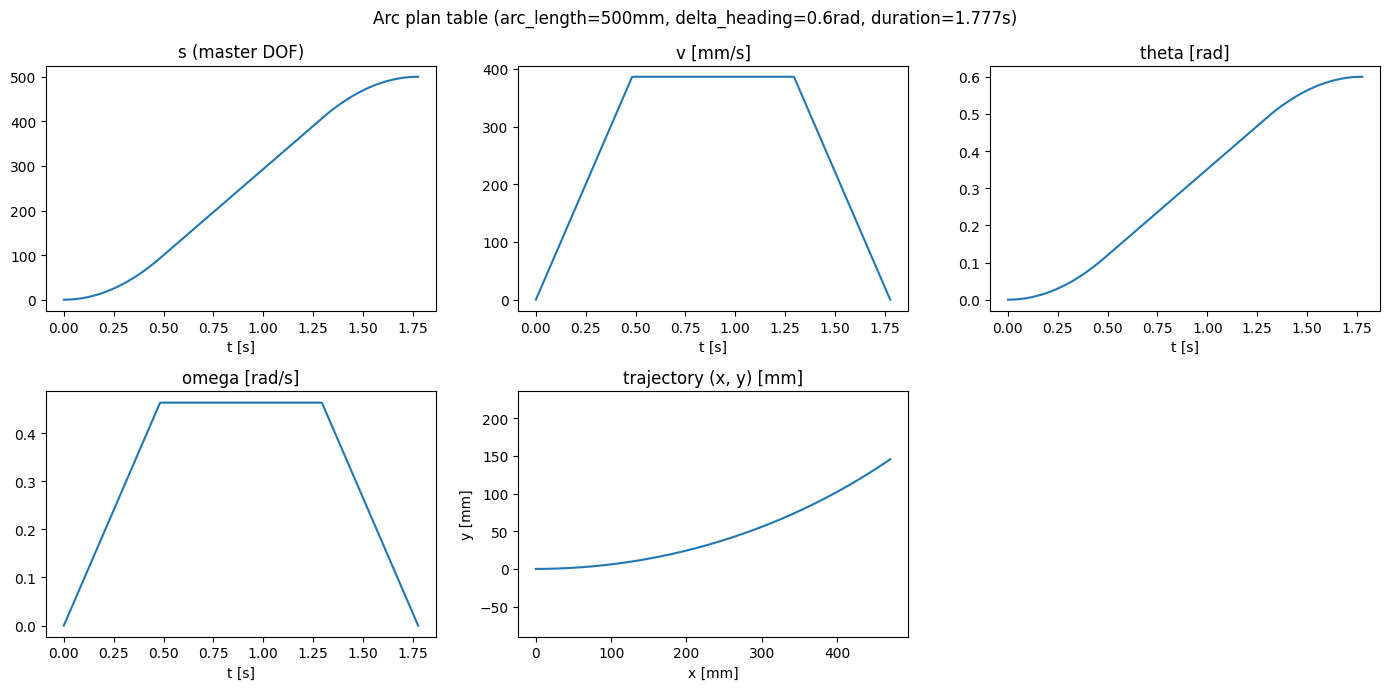

In [6]:
_ = plot_plan_table(
    arc_df, f"Arc plan table (arc_length=500mm, delta_heading=0.6rad, duration={arc_duration:.3f}s)",
    OUT_DIR / "drive_plan_table_arc.png")


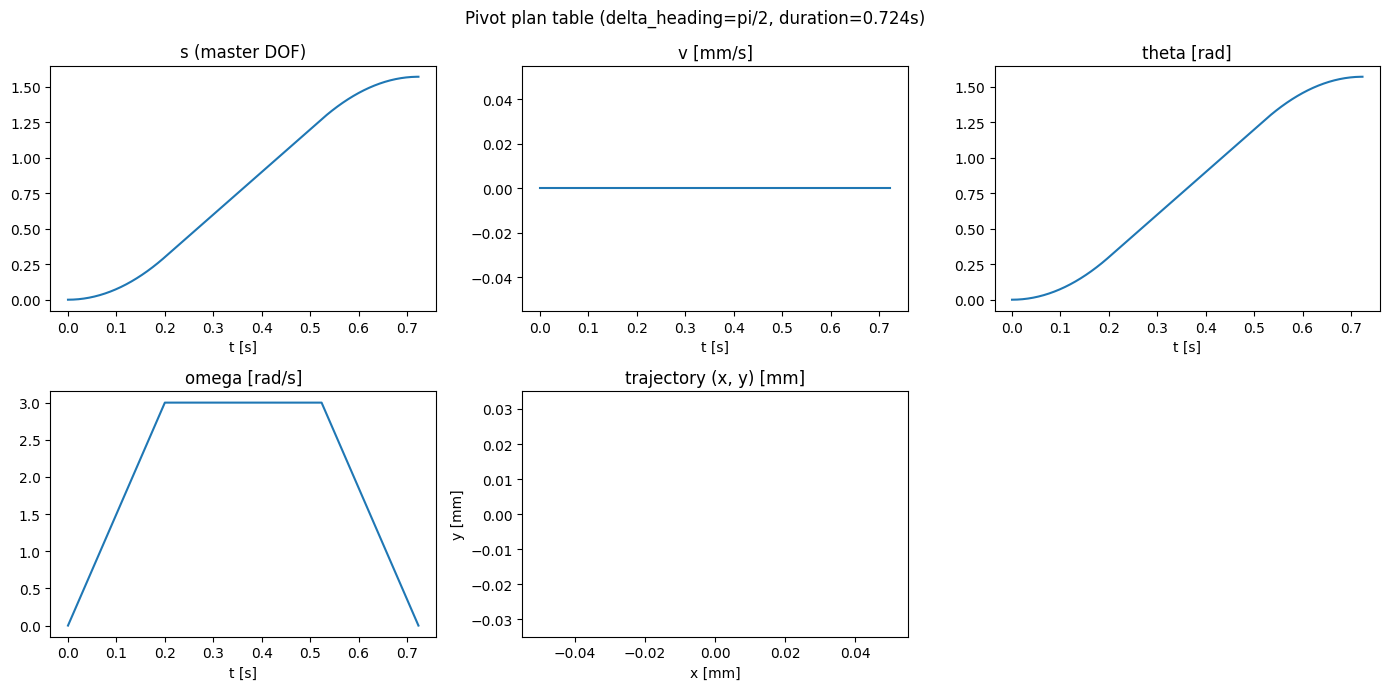

In [7]:
_ = plot_plan_table(
    pivot_df, f"Pivot plan table (delta_heading=pi/2, duration={pivot_duration:.3f}s)",
    OUT_DIR / "drive_plan_table_pivot.png")


## Reading the tables

- **Arc**: `v`/`omega` both ramp through the SAME jerk-limited master
  profile (path length is the master DOF; `omega = kappa * v` is always
  DERIVED, never independently solved — the issue's "one trajectory per
  segment" rule). `theta`/`x`/`y` are the closed-form constant-curvature
  pose (`arc_math.h::poseAlongArc`).
- **Pivot**: `v` is a literal `0.0` for the entire plan (no translation);
  the master DOF is HEADING — `s`/`theta` are numerically identical
  (`theta = anchor.h + s`), `omega`/`alpha` are the master profile's own
  velocity/acceleration channel directly. `x`/`y` stay pinned at the
  anchor for the whole plan (the trajectory panel is a single point).

Both tables are written to `tests/notebooks/out/drive_plan_table_{arc,pivot}.csv`
and the two figures to the matching `.png` files, alongside every other
notebook's own `out/` convention.
